In [1]:
import phoebe
import numpy as np
import astropy.units as u
from phoebe.parameters.dataset import _mesh_columns

import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [ ]:
b = phoebe.default_binary()

# Time points are in days
times = np.linspace(0, 1, 100)

# Use all columns for the mesh dataset
COLUMNS = _mesh_columns
b.add_dataset('mesh', times=times, columns=COLUMNS, dataset='mesh01')
b.add_dataset('orb', compute_times=times, dataset='orb01')
b.add_dataset('lc', compute_times=times, passband='Bolometric:900-40000', dataset='lc01')
b.set_value('distance@system', 10*u.pc.to(u.solRad))
b.set_value_all('gravb_bol', 0.0)
b.set_value_all('ld_mode', 'manual')
b.set_value_all('ld_func', 'linear')
b.set_value_all('ld_coeffs', [0.])
b.set_value_all('ld_mode_bol', 'manual')
b.set_value_all('ld_func_bol', 'linear')
b.set_value_all('ld_coeffs_bol', [0.])
b.set_value_all('atm', 'blackbody')
b.set_value_all('irrad_method', 'none')
b.compute_pblums(pbflux=True, set_value=True)  # updates pblums (and optionally pbflux)
b.compute_ld_coeffs(ld_mode='manual', ld_func='linear', ld_coeffs=[0.])
b.run_compute(irrad_method='none', coordinates='uvw', ltte=False, ntriangles=20480)
body1 = default_icosphere(b.get_parameter('mass@primary@component').value)

100%|██████████| 100/100 [00:02<00:00, 46.07it/s]


<ParameterSet: 6219 parameters | kinds: orb, mesh, lc>

In [6]:
diffs_phoebe = -2.5*np.log10(b.get_parameter('fluxes@lc01@model').value)

In [7]:
phoebe_diff = -2.5*np.log10(b.get_parameter('fluxes@lc01@model').value)

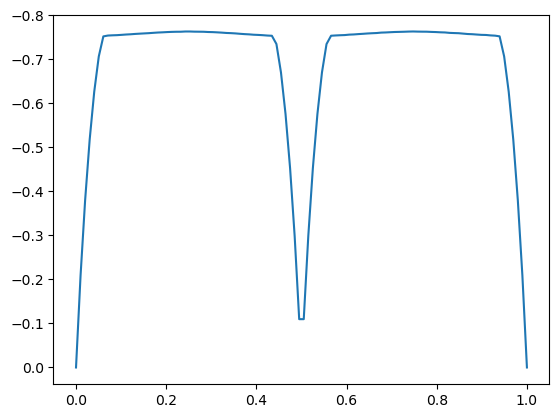

In [8]:
plt.plot(times, phoebe_diff-phoebe_diff[0]);
plt.gca().invert_yaxis();